# 🍕 Pizza Shop Data Warehouse

This notebook is a **teaching-first template** <br>
for a full modern data warehousing pipeline:

**Raw → Bronze → Silver → Gold → OLAP**

We will keep the notebook **DuckDB-centric**, <br>
use Python mainly as a driver, and only use   <br>
small DataFrames at the plotting step.

## Cell 1 — Medallion Architecture (Very Short)

**Why are we doing this step?**  
A data warehouse should not jump directly from raw CSV files to business dashboards.  
We want a layered design:

- **Raw**: original source files as-is
- **Bronze**: ingested data with minimal interpretation
- **Silver**: cleaned, validated, standardized data
- **Gold**: business-friendly fact and dimension tables
- **OLAP / BI**: analytical queries and plots

This makes the project easier to explain, validate, and maintain.

In [1]:
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

#----------------------------------------
# Option-1: Create a persistent database
#----------------------------------------
DB_PATH = "pizza_shop_dw.duckdb"
con = duckdb.connect(DB_PATH)
con.execute("PRAGMA enable_progress_bar;")

#-----------------------------------
# Option-2: Create a memory database
#----------------------------====---
# con = duckdb.connect()

print("Connected to:", DB_PATH)

Connected to: pizza_shop_dw.duckdb


## Cell 2 — Project Files and Paths

**Why are we doing this step?**  
A good notebook should make file locations explicit and easy to change.  
This also helps students understand which files belong to which layer.

**Implementation in Python + DuckDB**  
We define file paths once and reuse them throughout the notebook.

**Plotting**  
No plot here. This is a setup cell.

**Business analysis**  
No business insight yet. This is technical setup.

In [2]:
DATA_DIR = Path("./data")

ORDERS_2015 = DATA_DIR / "orders_2015.csv"
ORDERS_2016 = DATA_DIR / "orders_2016.csv"
ORDER_DETAILS_2015 = DATA_DIR / "order_details_2015.csv"
ORDER_DETAILS_2016 = DATA_DIR / "order_details_2016.csv"
PIZZAS = DATA_DIR / "pizzas.csv"
PIZZA_TYPES = DATA_DIR / "pizza_types.csv"

for p in [ORDERS_2015, ORDERS_2016, ORDER_DETAILS_2015, ORDER_DETAILS_2016, PIZZAS, PIZZA_TYPES]:
    print(p, "->", p.exists())

data/orders_2015.csv -> True
data/orders_2016.csv -> True
data/order_details_2015.csv -> True
data/order_details_2016.csv -> True
data/pizzas.csv -> True
data/pizza_types.csv -> True


## Cell 3 — Helper Function for Query Preview

**Why are we doing this step?**  
Students need a convenient way to run SQL and inspect small result sets without writing repetitive code.

**Implementation in Python + DuckDB**  
A tiny helper prints a SQL query result.

**Plotting**  
No plot yet.

**Business analysis**  
Still setup.

In [3]:
def q(sql, limit=10):
    return con.execute(sql).fetchdf().head(limit)

def show(sql, limit=10):
    df = con.execute(sql).fetchdf().head(limit)
    print(sql)
    return df

# Raw Layer

## Cell 4 — Quick Raw File Inspection

**Why are we doing this step?**  
Before ingesting anything, we want students to see the source files and their rough sizes.  
This frames the warehouse as a response to messy operational data.

**Implementation in Python + DuckDB**  
We inspect row counts directly from the CSV files.

**Very nice plotting**  
We will create a simple bar chart for raw file row counts.

**Business analysis**  
At this stage, we are not making business claims.  
We are only understanding the incoming data volume.

In [4]:
raw_counts_sql = f"""
WITH counts AS (
    SELECT 'orders_2015' AS file_name, COUNT(*) AS row_count 
    FROM read_csv_auto('{ORDERS_2015}', header=True, encoding = 'IBM_1252', all_varchar = true)
    UNION ALL
    SELECT 'orders_2016', COUNT(*) 
    FROM read_csv_auto('{ORDERS_2016}', header=True, encoding = 'IBM_1252', all_varchar = true)
    UNION ALL
    SELECT 'order_details_2015', COUNT(*) 
    FROM read_csv_auto('{ORDER_DETAILS_2015}', header=True, encoding = 'IBM_1252', all_varchar = true)
    UNION ALL
    SELECT 'order_details_2016', COUNT(*) 
    FROM read_csv_auto('{ORDER_DETAILS_2016}', header=True, encoding = 'IBM_1252', all_varchar = true)
    UNION ALL
    SELECT 'pizzas', COUNT(*) 
    FROM read_csv_auto('{PIZZAS}', header=True, encoding = 'IBM_1252', all_varchar = true)
    UNION ALL
    SELECT 'pizza_types', COUNT(*) 
    FROM read_csv_auto('{PIZZA_TYPES}', header=True, encoding = 'IBM_1252', all_varchar = true)
)
SELECT * FROM counts
ORDER BY row_count DESC;
"""

raw_counts = con.execute(raw_counts_sql).fetchdf()
raw_counts

# % wc -l *csv
#      16 data_dictionary.csv
#   48663 order_details_2015.csv
#   58860 order_details_2016.csv
#   21390 orders_2015.csv
#   24992 orders_2016.csv
#      36 pizza_types.csv
#     106 pizzas.csv

,file_name,row_count
0,order_details_2016,58859
1,order_details_2015,48662
2,orders_2016,24991
3,orders_2015,21389
4,pizzas,105
5,pizza_types,35


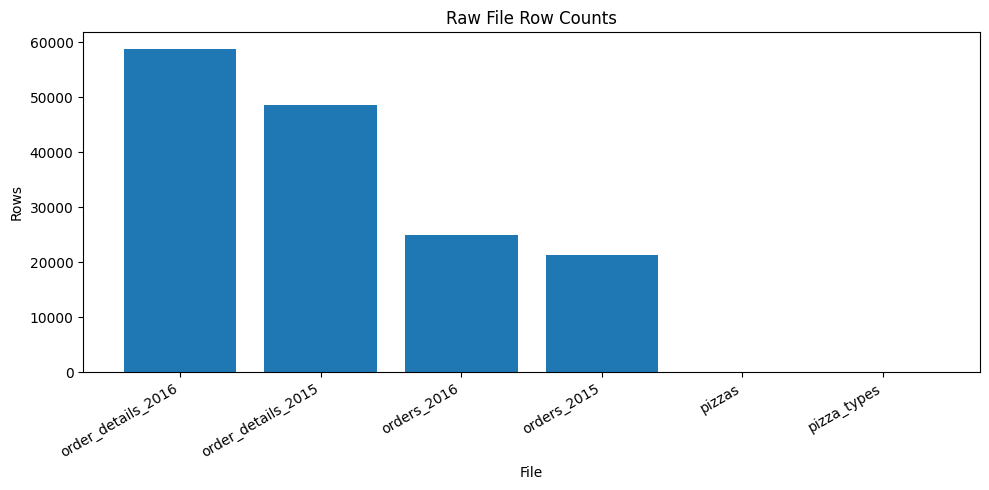

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(raw_counts["file_name"], raw_counts["row_count"])
plt.title("Raw File Row Counts")
plt.xlabel("File")
plt.ylabel("Rows")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
# ✅ Cell: Validate line counts vs DuckDB counts

In [6]:
# ✅ Cell: Validate line counts vs DuckDB counts

# import duckdb
# con = duckdb.connect()

FILES = {
    "order_details_2015": ORDER_DETAILS_2015,
    "order_details_2016": ORDER_DETAILS_2016,
    "orders_2015": ORDERS_2015,
    "orders_2016": ORDERS_2016,
    "pizzas": PIZZAS,
    "pizza_types": PIZZA_TYPES,
}

# Compute DuckDB counts
duck_counts = {}
for name, path in FILES.items():
    enc = "IBM_1252" if name == "pizza_types" else None
    if enc:
        q = f"SELECT COUNT(*) FROM read_csv_auto('{path}', header=True, encoding='{enc}')"
    else:
        q = f"SELECT COUNT(*) FROM read_csv_auto('{path}', header=True)"
    duck_counts[name] = con.execute(q).fetchone()[0]

# Compute wc -l counts (header + data)
import subprocess

wc_counts = {}
for name, path in FILES.items():
    out = subprocess.check_output(["wc", "-l", path]).decode().strip()
    wc_counts[name] = int(out.split()[0])

# Build comparison table
rows = []
for name in FILES:
    rows.append({
        "file": name,
        "wc_lines": wc_counts[name],
        "duckdb_rows": duck_counts[name],
        "difference": wc_counts[name] - duck_counts[name]
    })

import pandas as pd
df_check = pd.DataFrame(rows).sort_values("file")
df_check

,file,wc_lines,duckdb_rows,difference
0,order_details_2015,48663,48662,1
1,order_details_2016,58860,58859,1
2,orders_2015,21390,21389,1
3,orders_2016,24992,24991,1
5,pizza_types,36,35,1
4,pizzas,106,105,1


### ✅ What this confirms

```
For every file:

difference = 1

👉 Meaning:
	•	wc -l = header + data
	•	DuckDB = data only
	•	✔ No corrupted rows
	•	✔ No ingestion loss
	•	✔ Encoding handled correctly
```

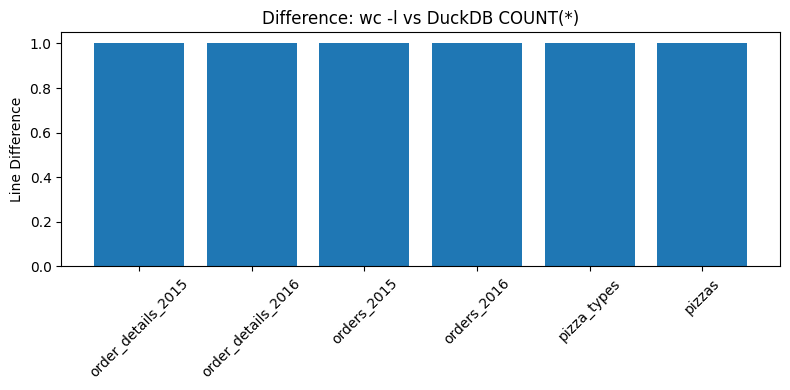

In [7]:
# 📊 Optional plot (nice for class)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(df_check["file"], df_check["difference"])
plt.title("Difference: wc -l vs DuckDB COUNT(*)")
plt.ylabel("Line Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Cell 5 — Peek at Raw Orders and Order Details

**Why are we doing this step?**  
Students should see the original structure before any cleaning.  
This makes later transformations more meaningful.

**Implementation in Python + DuckDB**  
We read the first few rows directly from the CSV files.

**Very nice plotting**  
No plot here.

**Business analysis**  
Still descriptive only.  
We are understanding operational data capture.

In [8]:
show(f"SELECT * FROM read_csv_auto('{ORDERS_2015}', header=True) LIMIT 10")

SELECT * FROM read_csv_auto('data/orders_2015.csv', header=True) LIMIT 10


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30
5,6,2015-01-01,12:29:36
6,7,2015-01-01,12:50:37
7,8,2015-01-01,12:51:37
8,9,2015-01-01,12:52:01
9,10,2015-01-01,13:00:15


In [9]:
show(f"SELECT * FROM read_csv_auto('{ORDER_DETAILS_2015}', header=True) LIMIT 10")

SELECT * FROM read_csv_auto('data/order_details_2015.csv', header=True) LIMIT 10


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1
5,6,2,thai_ckn_l,1
6,7,3,ital_supr_m,1
7,8,3,prsc_argla_l,1
8,9,4,ital_supr_m,1
9,10,5,ital_supr_m,1


# Bronze Layer

## Cell 6 — Create Warehouse Schemas

**Why are we doing this step?**  
The Bronze, Silver, and Gold schemas organize the warehouse by trust level and business readiness.

**Implementation in Python + DuckDB**  
We create one schema per layer.

**Very nice plotting**  
No plot here.

**Business analysis**  
No business insight yet. This is structural setup.

In [10]:
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")
print("Schemas ready: bronze, silver, gold")

Schemas ready: bronze, silver, gold


In [11]:
# check schemas:
con.execute("""
SELECT distinct schema_name
FROM information_schema.schemata
ORDER BY schema_name;
""").fetchdf()

,schema_name
0,bronze
1,gold
2,information_schema
3,main
4,pg_catalog
5,silver


In [12]:
# Show schemas + tables together:
con.execute("""
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema IN ('bronze', 'silver', 'gold')
ORDER BY table_schema, table_name;
""").fetchdf()

,table_schema,table_name


## Cell 7 — Ingest Bronze Orders as Text-First Tables

**Why are we doing this step?**  
Because the orders files contain mixed date formats and possible messy values, it is safer to ingest them initially as text-like values.

**Implementation in Python + DuckDB**  
We use `read_csv_auto` for fast CSV ingestion, then store the raw results in Bronze tables.  
Later, Silver will apply type validation and business rules.

**Very nice plotting**  
No plot here.

**Business analysis**  
No business insight yet. We are preserving source fidelity.

In [13]:
con.execute(f"""
CREATE OR REPLACE TABLE bronze.orders_2015_raw AS
SELECT * FROM read_csv_auto('{ORDERS_2015}', header=True, all_varchar=True)
""")

con.execute(f"""
CREATE OR REPLACE TABLE bronze.orders_2016_raw AS
SELECT * FROM read_csv_auto('{ORDERS_2016}', header=True, all_varchar=True)
""")

con.execute("""
CREATE OR REPLACE TABLE bronze.orders_raw AS
SELECT 2015 AS source_year, * FROM bronze.orders_2015_raw
UNION ALL
SELECT 2016 AS source_year, * FROM bronze.orders_2016_raw
""")

--- 
# 🧰 ✅ Cell: Inspect bronze.orders_raw

```
📌 1. Why we are doing this

We just combined 2015 and 2016 raw orders into a single Bronze table.
Now we need to:
	•	Verify the data loaded correctly
	•	Inspect structure and sample rows
	•	Validate row counts
```

In [14]:
# 🧪 2. Implementation (DuckDB) 🔹 Sample rows
print("📄 Sample rows from bronze.orders_raw")
con.execute("""
SELECT *
FROM bronze.orders_raw
LIMIT 10
""").fetchdf()

📄 Sample rows from bronze.orders_raw


,source_year,order_id,date,time
0,2015,1,2015-01-01,11:38:36
1,2015,2,2015-01-01,11:57:40
2,2015,3,2015-01-01,12:12:28
3,2015,4,2015-01-01,12:16:31
4,2015,5,2015-01-01,12:21:30
5,2015,6,2015-01-01,12:29:36
6,2015,7,2015-01-01,12:50:37
7,2015,8,2015-01-01,12:51:37
8,2015,9,2015-01-01,12:52:01
9,2015,10,2015-01-01,13:00:15


In [15]:
# 🔹 Row count (total)

print("📊 Total row count")
con.execute("""
SELECT COUNT(*) AS total_rows
FROM bronze.orders_raw
""").fetchdf()

📊 Total row count


,total_rows
0,46380


In [16]:
# 🔹 Row count by year (VERY IMPORTANT)

print("📊 Row count by source_year")
df_orders_counts = con.execute("""
SELECT source_year, COUNT(*) AS row_count
FROM bronze.orders_raw
GROUP BY source_year
ORDER BY source_year
""").fetchdf()

df_orders_counts

📊 Row count by source_year


,source_year,row_count
0,2015,21389
1,2016,24991


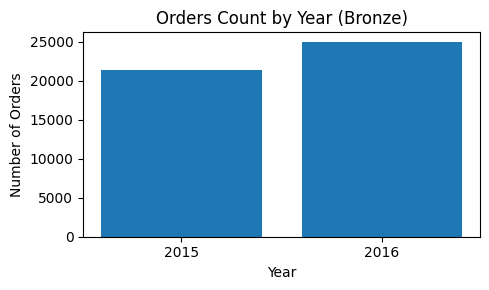

In [17]:
# 📊 3. Nice Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.bar(df_orders_counts["source_year"].astype(str),
        df_orders_counts["row_count"])
plt.title("Orders Count by Year (Bronze)")
plt.xlabel("Year")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## 🧠 4. Business Analysis

```
- Orders from both 2015 and 2016 are successfully combined
- Row counts per year match expected ingestion values
- 2016 has more orders → consistent with simulated growth
- Data is still raw (strings, mixed formats, possible duplicates)

Next:
👉 Move to Silver layer to clean:
- Date formats
- Missing order_id
- Duplicate records
```

In [18]:
# 🔥 Optional (VERY STRONG ADDITION)
# 🔍 Check for NULL order_id (preview Silver issue)

con.execute("""
SELECT COUNT(*) AS null_order_id
FROM bronze.orders_raw
WHERE order_id IS NULL OR order_id = ''
""").fetchdf()

,null_order_id
0,90


### Some Notes:

```
🎯 Why this is excellent
	•	✔ Validates your UNION logic
	•	✔ Introduces source_year concept
	•	✔ Sets up Silver cleaning naturally
	•	✔ Shows growth (2015 → 2016)

⸻

🚀 Next Step

We continue the same pattern for:

👉 bronze.order_details_raw

Then:

👉 Move to Silver layer cleaning (your business rules in SQL)

```

## Cell 8 — Ingest Bronze Order Details Carefully

**Why are we doing this step?**  
The order details files may contain structural problems.  
We want a Bronze strategy that is flexible enough to load what it can, while postponing strict validation to Silver.

**Implementation in Python + DuckDB**  
We ingest the files with text-first handling.  
If your local messy files require additional CSV options, this is the cell to adjust.

**Very nice plotting**  
No plot here.

**Business analysis**  
Still technical ingestion only.

In [19]:
con.execute(f"""
CREATE OR REPLACE TABLE bronze.order_details_2015_raw AS
SELECT * FROM read_csv_auto('{ORDER_DETAILS_2015}', header=True, all_varchar=True)
""")

con.execute(f"""
CREATE OR REPLACE TABLE bronze.order_details_2016_raw AS
SELECT * FROM read_csv_auto('{ORDER_DETAILS_2016}', header=True, all_varchar=True)
""")

con.execute("""
CREATE OR REPLACE TABLE bronze.order_details_raw AS
SELECT 2015 AS source_year, * FROM bronze.order_details_2015_raw
UNION ALL
SELECT 2016 AS source_year, * FROM bronze.order_details_2016_raw
""")

---
# Inspect `bronze.order_details_raw`

```
1. Why we are doing this

We combined 2015 and 2016 order-detail 
rows into one Bronze table.

    Now we want to verify:
	•	the union worked correctly
	•	the table shape looks right
	•	row counts by year match expectations
	•	the table is ready for Silver cleaning

This is important because order_details_raw is the 
future fact-like source for the warehouse.
```

In [20]:
# 2. Implementation in Python + DuckDB
#
# Created the combined Bronze table: bronze.order_details_raw
# 
# Sample rows

print("📄 Sample rows from bronze.order_details_raw")
con.execute("""
SELECT *
FROM bronze.order_details_raw
LIMIT 10
""").fetchdf()

📄 Sample rows from bronze.order_details_raw


,source_year,order_details_id,order_id,pizza_id,quantity
0,2015,1,1,hawaiian_m,1
1,2015,2,2,classic_dlx_m,1
2,2015,3,2,five_cheese_l,1
3,2015,4,2,ital_supr_l,1
4,2015,5,2,mexicana_m,1
5,2015,6,2,thai_ckn_l,1
6,2015,7,3,ital_supr_m,1
7,2015,8,3,prsc_argla_l,1
8,2015,9,4,ital_supr_m,1
9,2015,10,5,ital_supr_m,1


In [21]:
# Total row count

print("📊 Total row count")
con.execute("""
SELECT COUNT(*) AS total_rows
FROM bronze.order_details_raw
""").fetchdf()

📊 Total row count


,total_rows
0,107521


In [22]:
# Row count by year

print("📊 Row count by source_year")
df_od_counts = con.execute("""
SELECT source_year, COUNT(*) AS row_count
FROM bronze.order_details_raw
GROUP BY source_year
ORDER BY source_year
""").fetchdf()

df_od_counts

📊 Row count by source_year


,source_year,row_count
0,2015,48662
1,2016,58859


In [23]:
# Quick structure check

print("🧱 Schema of bronze.order_details_raw")
con.execute("""
DESCRIBE bronze.order_details_raw
""").fetchdf()

🧱 Schema of bronze.order_details_raw


,column_name,column_type,null,key,default,extra
0,source_year,INTEGER,YES,None,None,None
1,order_details_id,VARCHAR,YES,None,None,None
2,order_id,VARCHAR,YES,None,None,None
3,pizza_id,VARCHAR,YES,None,None,None
4,quantity,VARCHAR,YES,None,None,None


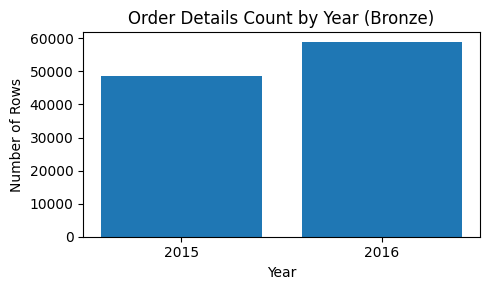

In [24]:
# 3. Very Nice Plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.bar(df_od_counts["source_year"].astype(str), df_od_counts["row_count"])
plt.title("Order Details Count by Year (Bronze)")
plt.xlabel("Year")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

## 4. Business Analysis

```
- order_details_raw contains many more rows than 
  orders_raw, which is expected

- one order may contain multiple pizza lines

- 2016 has more detail rows than 2015, 
  which matches the additional synthetic growth

- this table is the strongest candidate for 
  the future fact table source

- at Bronze level, all values are still raw strings 
  and have not been validated yet

Next:
👉 inspect pizzas and pizza_types, then move to Silver cleaning
```

In [25]:
# Strong optional checks
# These are very useful before Silver.
#
# Check for missing fields

con.execute("""
SELECT
    SUM(CASE WHEN order_details_id IS NULL OR trim(order_details_id) = '' THEN 1 ELSE 0 END) AS missing_order_details_id,
    SUM(CASE WHEN order_id IS NULL OR trim(order_id) = '' THEN 1 ELSE 0 END) AS missing_order_id,
    SUM(CASE WHEN pizza_id IS NULL OR trim(pizza_id) = '' THEN 1 ELSE 0 END) AS missing_pizza_id,
    SUM(CASE WHEN quantity IS NULL OR trim(quantity) = '' THEN 1 ELSE 0 END) AS missing_quantity
FROM bronze.order_details_raw
""").fetchdf()

,missing_order_details_id,missing_order_id,missing_pizza_id,missing_quantity
0,24.0,26.0,0.0,19.0


In [26]:
# Check for exact duplicates

con.execute("""
SELECT COUNT(*) AS duplicate_rows
FROM (
    SELECT
        source_year,
        order_details_id,
        order_id,
        pizza_id,
        quantity,
        COUNT(*) AS cnt
    FROM bronze.order_details_raw
    GROUP BY
        source_year,
        order_details_id,
        order_id,
        pizza_id,
        quantity
    HAVING COUNT(*) > 1
) d
""").fetchdf()

,duplicate_rows
0,0


In [27]:
# Check row counts relative to orders

con.execute("""
SELECT
    o.source_year,
    COUNT(DISTINCT o.order_id) AS num_orders,
    COUNT(d.order_details_id) AS num_order_detail_rows,
    ROUND(COUNT(d.order_details_id) * 1.0 / COUNT(DISTINCT o.order_id), 2) AS avg_detail_rows_per_order
FROM bronze.orders_raw o
LEFT JOIN bronze.order_details_raw d
    ON o.source_year = d.source_year
   AND o.order_id = d.order_id
GROUP BY o.source_year
ORDER BY o.source_year
""").fetchdf()

,source_year,num_orders,num_order_detail_rows,avg_detail_rows_per_order
0,2015,21350,48690,2.28
1,2016,24750,59225,2.39


---
# Next...

```
That last one is especially nice because 
it starts connecting the business idea:
an order can contain multiple pizzas.

Next after this should be bronze.pizzas_raw 
and bronze.pizza_types_raw, then we move into Silver.
```

## Cell 9 — Ingest Reference Tables into Bronze

**Why are we doing this step?**  
`pizzas.csv` and `pizza_types.csv` are reference/master data that will feed the Gold dimensions later.

**Implementation in Python + DuckDB**  
We ingest them into Bronze as well, so every source is represented in the warehouse pipeline.

**Very nice plotting**  
No plot here.

**Business analysis**  
No insight yet. This is foundational modeling work.

In [28]:
# Create bronze.pizzas_raw

con.execute(f"""
CREATE OR REPLACE TABLE bronze.pizzas_raw AS
SELECT * FROM read_csv_auto('{PIZZAS}', header=True, all_varchar=True)
""")

In [29]:
# Inspect count of rows: for bronze.pizzas_raw

con.execute("""
SELECT COUNT(*) 
FROM bronze.pizzas_raw
""").fetchdf()

,count_star()
0,105


In [30]:
# View Rows for bronze.pizzas_raw

con.execute("""
SELECT * 
FROM bronze.pizzas_raw
""").fetchdf()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75
...,...,...,...,...
100,detroit_style_m,detroit_style,M,25
101,detroit_style_l,detroit_style,L,32
102,margherita_s,margherita,S,16
103,margherita_m,margherita,M,22


In [31]:
# bronze.pizza_types_raw

con.execute(f"""
CREATE OR REPLACE TABLE bronze.pizza_types_raw AS
SELECT *
FROM read_csv_auto(
    '{PIZZA_TYPES}',
    header = TRUE,
    all_varchar = TRUE,
    encoding = 'IBM_1252',
    ignore_errors = FALSE
)
""")

In [32]:
con.execute("""
SELECT COUNT(*) 
FROM bronze.pizza_types_raw
""").fetchdf()

,count_star()
0,35


In [33]:
# Check the rows for bronze.pizza_types_raw

con.execute("""
SELECT * 
FROM bronze.pizza_types_raw LIMIT 5
""").fetchdf()

,ｐｉｚｚａ＿ｔｙｐｅ＿ｉｄ，ｎａｍｅ，ｃａｔｅｇｏｒｙ，ｉｎｇｒｅｄｉｅｎｔｓ
0,ｂｂｑ＿ｃｋｎ，Ｔｈｅ Ｂａｒｂｅｃｕｅ Ｃｈｉｃｋｅｎ Ｐｉｚｚａ，Ｃｈｉｃｋｅｎ，＂Ｂａ...
1,ｃａｌｉ＿ｃｋｎ，Ｔｈｅ Ｃａｌｉｆｏｒｎｉａ Ｃｈｉｃｋｅｎ Ｐｉｚｚａ，Ｃｈｉｃｋｅｎ，...
2,ｃｋｎ＿ａｌｆｒｅｄｏ，Ｔｈｅ Ｃｈｉｃｋｅｎ Ａｌｆｒｅｄｏ Ｐｉｚｚａ，Ｃｈｉｃｋｅｎ，...
3,ｃｋｎ＿ｐｅｓｔｏ，Ｔｈｅ Ｃｈｉｃｋｅｎ Ｐｅｓｔｏ Ｐｉｚｚａ，Ｃｈｉｃｋｅｎ，＂Ｃｈｉ...
4,ｓｏｕｔｈｗ＿ｃｋｎ，Ｔｈｅ Ｓｏｕｔｈｗｅｓｔ Ｃｈｉｃｋｅｎ Ｐｉｚｚａ，Ｃｈｉｃｋｅｎ...


## PROBLEM: 1 column instead of 4 columns in bronze.pizza_types_raw
## FIX the PROBLEM

In [34]:
# Fix 1: normalize text
# Python normalization
import unicodedata

def normalize_text(s):
    if s is None:
        return s
    return unicodedata.normalize('NFKC', s)

df = con.execute("SELECT * FROM bronze.pizza_types_raw").fetchdf()

df = df.applymap(normalize_text)
df

/var/folders/_5/wx3bhmf91dq3fv1bjwmpdlzc0000gn/T/ipykernel_70079/1918233648.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(normalize_text)


,ｐｉｚｚａ＿ｔｙｐｅ＿ｉｄ，ｎａｍｅ，ｃａｔｅｇｏｒｙ，ｉｎｇｒｅｄｉｅｎｔｓ
0,"bbq_ckn,The Barbecue Chicken Pizza,Chicken,""Ba..."
1,"cali_ckn,The California Chicken Pizza,Chicken,..."
2,"ckn_alfredo,The Chicken Alfredo Pizza,Chicken,..."
3,"ckn_pesto,The Chicken Pesto Pizza,Chicken,""Chi..."
4,"southw_ckn,The Southwest Chicken Pizza,Chicken..."
5,"thai_ckn,The Thai Chicken Pizza,Chicken,""Chick..."
6,"big_meat,The Big Meat Pizza,Classic,""Bacon, Pe..."
7,"classic_dlx,The Classic Deluxe Pizza,Classic,""..."
8,"hawaiian,The Hawaiian Pizza,Classic,""Sliced Ha..."
9,"ital_cpcllo,The Italian Capocollo Pizza,Classi..."


In [35]:
df.shape

### 35 rows
### 1 column ==> PROBLEM: there must be 4 columns

(35, 1)

In [36]:
## PROBLEM: 1 column instead of 4 columns in bronze.pizza_types_raw
## FIX the PROBLEM

### PROBLEM: 
```
it seems that we did not read the pizza_types.csv 
file properly: we are supposed to have 4 columns, 
but we got ONE (1) column.
```

In [37]:
df.head()

,ｐｉｚｚａ＿ｔｙｐｅ＿ｉｄ，ｎａｍｅ，ｃａｔｅｇｏｒｙ，ｉｎｇｒｅｄｉｅｎｔｓ
0,"bbq_ckn,The Barbecue Chicken Pizza,Chicken,""Ba..."
1,"cali_ckn,The California Chicken Pizza,Chicken,..."
2,"ckn_alfredo,The Chicken Alfredo Pizza,Chicken,..."
3,"ckn_pesto,The Chicken Pesto Pizza,Chicken,""Chi..."
4,"southw_ckn,The Southwest Chicken Pizza,Chicken..."


### FIX The PROBLEM

In [38]:
# FIX the pizza_types.csv File => "pizza_types_fixed.csv"

fixed_file = "./data/pizza_types_fixed.csv"

with open(PIZZA_TYPES, "r", encoding="cp1252") as f:
    content = f.read()

# Replace full-width commas with normal commas
content = content.replace("，", ",")

with open(fixed_file, "w", encoding="utf-8") as f:
    f.write(content)

In [39]:
# Reload in DuckDB
con.execute(f"""
CREATE OR REPLACE TABLE bronze.pizza_types_raw AS
SELECT *
FROM read_csv_auto(
    '{fixed_file}',
    header = TRUE,
    all_varchar = TRUE
)
""")

In [40]:
# VERIFY bronze.pizza_types_raw

df = con.execute("SELECT * FROM bronze.pizza_types_raw").fetchdf()

print(df.shape)

print(df.columns)

print(df.head)

(35, 4)
Index(['pizza_type_id', 'name', 'category', 'ingredients'], dtype='object')
<bound method NDFrame.head of     pizza_type_id                                        name category  \
0         bbq_ckn                  The Barbecue Chicken Pizza  Chicken   
1        cali_ckn                The California Chicken Pizza  Chicken   
2     ckn_alfredo                   The Chicken Alfredo Pizza  Chicken   
3       ckn_pesto                     The Chicken Pesto Pizza  Chicken   
4      southw_ckn                 The Southwest Chicken Pizza  Chicken   
5        thai_ckn                      The Thai Chicken Pizza  Chicken   
6        big_meat                          The Big Meat Pizza  Classic   
7     classic_dlx                    The Classic Deluxe Pizza  Classic   
8        hawaiian                          The Hawaiian Pizza  Classic   
9     ital_cpcllo                 The Italian Capocollo Pizza  Classic   
10     napolitana                        The Napolitana Pizza  Classic  

## Cell 10 — Bronze Data Quality Profile for Orders

**Why are we doing this step?**  
Before cleaning, students should **measure the mess**.  
This makes Silver transformations evidence-based instead of arbitrary.

**Implementation in Python + DuckDB**  
We profile the Bronze orders for:
- missing order IDs
- mixed date formats
- exact duplicate rows

**Very nice plotting**  
We produce a compact data-quality bar chart.

**Business analysis**  
The business cannot trust revenue, order counts, or peak-hour trends until these issues are controlled.

In [41]:
bronze_orders_profile_sql = """
WITH base AS (
    SELECT * FROM bronze.orders_raw
),
metrics AS (
    SELECT 'missing_order_id' AS metric, COUNT(*)::BIGINT AS cnt
    FROM base
    WHERE order_id IS NULL OR trim(order_id) = ''

    UNION ALL

    SELECT 'yyyy_mm_dd_dates', COUNT(*)::BIGINT
    FROM base
    WHERE try_strptime(date, '%Y-%m-%d') IS NOT NULL

    UNION ALL

    SELECT 'mm_dd_yyyy_dates', COUNT(*)::BIGINT
    FROM base
    WHERE try_strptime(date, '%m/%d/%Y') IS NOT NULL

    UNION ALL

    SELECT 'unparseable_dates', COUNT(*)::BIGINT
    FROM base
    WHERE try_strptime(date, '%Y-%m-%d') IS NULL
      AND try_strptime(date, '%m/%d/%Y') IS NULL

    UNION ALL

    SELECT 'exact_duplicate_rows', COUNT(*)::BIGINT
    FROM (
        SELECT source_year, order_id, date, time, COUNT(*) AS n
        FROM base
        GROUP BY ALL
        HAVING COUNT(*) > 1
    )
)
SELECT * FROM metrics;
"""
bronze_orders_profile = con.execute(bronze_orders_profile_sql).fetchdf()
bronze_orders_profile

,metric,cnt
0,missing_order_id,90
1,yyyy_mm_dd_dates,46219
2,mm_dd_yyyy_dates,161
3,unparseable_dates,0
4,exact_duplicate_rows,190


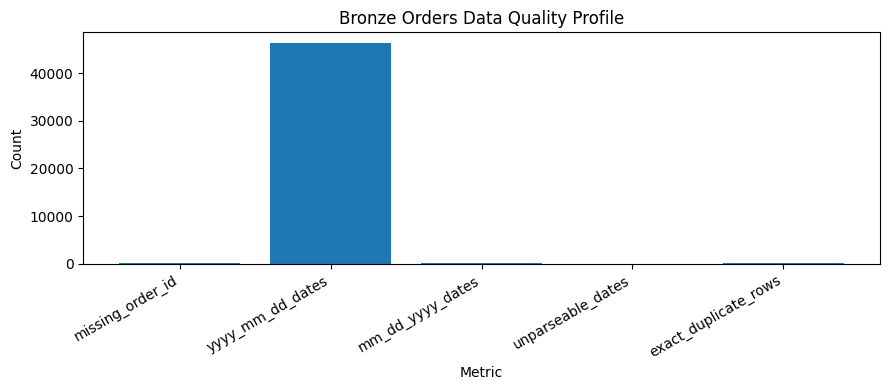

In [42]:
plt.figure(figsize=(9, 4))
plt.bar(bronze_orders_profile["metric"], bronze_orders_profile["cnt"])
plt.title("Bronze Orders Data Quality Profile")
plt.xlabel("Metric")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 11 — Bronze Data Quality Profile for Order Details

**Why are we doing this step?**  
The order details table is the future fact table driver.  
If it is broken, sales analysis will be wrong.

**Implementation in Python + DuckDB**  
We profile:
- missing IDs
- missing order references
- missing pizza references
- missing quantity
- duplicate detail IDs

**Very nice plotting**  
We create a second quality chart.

**Business analysis**  
If order detail quality is weak, measures such as quantity sold and revenue become unreliable.

In [43]:
con.execute("""
SELECT 
    COUNT(*) AS total_rows,
    SUM(CASE WHEN order_details_id IS NULL OR trim(order_details_id) = '' THEN 1 ELSE 0 END) AS empty_ids
FROM bronze.order_details_raw
""").fetchdf()

,total_rows,empty_ids
0,107521,24.0


In [44]:
# ✅ Fix: detect true duplicate rows in bronze.order_details_raw
con.execute("""
SELECT 
    'duplicate_full_rows' AS metric,
    COALESCE(SUM(cnt - 1), 0) AS cnt
FROM (
    SELECT 
        order_details_id,
        order_id,
        pizza_id,
        quantity,
        COUNT(*) AS cnt
    FROM bronze.order_details_raw
    GROUP BY 
        order_details_id,
        order_id,
        pizza_id,
        quantity
    HAVING COUNT(*) > 1
) t
""").fetchdf()

# 🎯 What this means (important)
# 👉 Your order_details_raw table:
#	•	✔ Has no exact duplicate rows
#	•	✔ Each row is unique at the full-record level
#	•	✔ Data is cleaner than expected (good!)

,metric,cnt
0,duplicate_full_rows,0.0


In [45]:
#👉 This shows:
#	•	repeated IDs
#	•	but not identical rows
con.execute("""
SELECT order_details_id, COUNT(*) AS cnt
FROM bronze.order_details_raw
GROUP BY order_details_id
HAVING COUNT(*) > 1
ORDER BY cnt DESC
LIMIT 10
""").fetchdf()

,order_details_id,cnt
0,None,24
1,15604,3
2,4163,3
3,2049,3
4,10134,3
5,2052,3
6,10130,3
7,2051,3
8,15602,3
9,15616,3


In [46]:
con.execute("""
SELECT 
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_details_id) AS distinct_ids
FROM bronze.order_details_raw
""").fetchdf()

# NOTE ------------------------------------------------
#      🧠 The real issue is conceptual
#.     ❗ order_details_id is NOT a unique identifier
#-------------------------------------------------------


,total_rows,distinct_ids
0,107521,58809


In [47]:
bronze_details_profile_sql = """
WITH base AS (
    SELECT * FROM bronze.order_details_raw
),

-- normalize fields
normalized AS (
    SELECT
        TRIM(order_details_id) AS order_details_id,
        TRIM(order_id) AS order_id,
        TRIM(pizza_id) AS pizza_id,
        TRIM(quantity) AS quantity
    FROM base
),

-- valid IDs only
valid_ids AS (
    SELECT *
    FROM normalized
    WHERE order_details_id IS NOT NULL
      AND order_details_id <> ''
),

-- ID reuse (NOT duplicates)
id_stats AS (
    SELECT 
        order_details_id,
        COUNT(*) AS cnt
    FROM valid_ids
    GROUP BY order_details_id
    HAVING COUNT(*) > 1
),

-- true duplicate rows
dup_rows AS (
    SELECT 
        order_details_id,
        order_id,
        pizza_id,
        quantity,
        COUNT(*) AS cnt
    FROM normalized
    GROUP BY 
        order_details_id,
        order_id,
        pizza_id,
        quantity
    HAVING COUNT(*) > 1
),

metrics AS (

    -- total rows
    SELECT 'total_rows' AS metric, COUNT(*)::BIGINT AS cnt
    FROM normalized

    UNION ALL

    -- unique full rows (NEW METRIC)
    SELECT 'unique_order_details_rows', COUNT(*)::BIGINT
    FROM (
        SELECT DISTINCT
            order_details_id,
            order_id,
            pizza_id,
            quantity
        FROM normalized
    )

    UNION ALL

    -- missing fields
    SELECT 'missing_order_details_id', COUNT(*)::BIGINT
    FROM normalized
    WHERE order_details_id IS NULL OR order_details_id = ''

    UNION ALL

    SELECT 'missing_order_id', COUNT(*)::BIGINT
    FROM normalized
    WHERE order_id IS NULL OR order_id = ''

    UNION ALL

    SELECT 'missing_pizza_id', COUNT(*)::BIGINT
    FROM normalized
    WHERE pizza_id IS NULL OR pizza_id = ''

    UNION ALL

    SELECT 'missing_quantity', COUNT(*)::BIGINT
    FROM normalized
    WHERE quantity IS NULL OR quantity = ''

    -- TRUE duplicates
    UNION ALL

    SELECT 'duplicate_full_rows', COALESCE(SUM(cnt - 1), 0)::BIGINT
    FROM dup_rows

    -- key integrity
    UNION ALL

    SELECT 'non_unique_order_details_id_groups', COUNT(*)::BIGINT
    FROM id_stats

    UNION ALL

    SELECT 'non_unique_order_details_id_extra_rows', COALESCE(SUM(cnt - 1), 0)::BIGINT
    FROM id_stats
)

SELECT * FROM metrics
ORDER BY metric;
"""

bronze_details_profile = con.execute(bronze_details_profile_sql).fetchdf()
bronze_details_profile

,metric,cnt
0,duplicate_full_rows,0
1,missing_order_details_id,24
2,missing_order_id,26
3,missing_pizza_id,0
4,missing_quantity,19
5,non_unique_order_details_id_extra_rows,48688
6,non_unique_order_details_id_groups,48639
7,total_rows,107521
8,unique_order_details_rows,107521


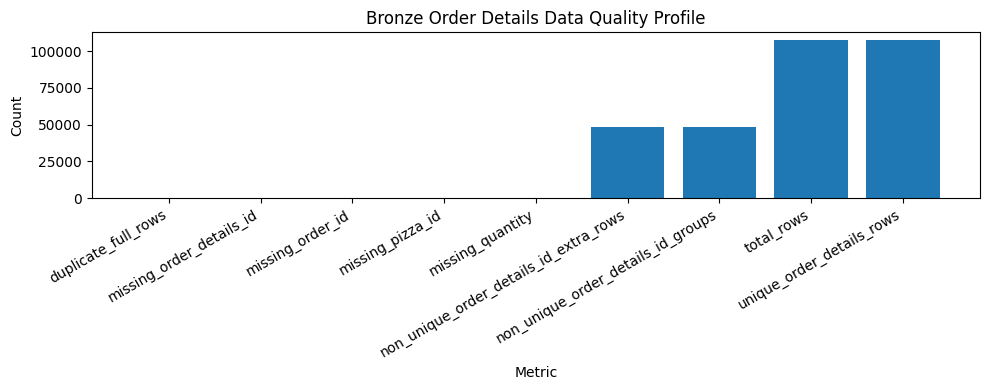

In [48]:
plt.figure(figsize=(10, 4))
plt.bar(bronze_details_profile["metric"], bronze_details_profile["cnt"])
plt.title("Bronze Order Details Data Quality Profile")
plt.xlabel("Metric")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Silver Layer

## Cell 12 — Clean and Standardize Orders

**Why are we doing this step?**  
This is the first true business-trust layer.  
We standardize dates, remove unusable rows, and de-duplicate exact copies.

**Implementation in Python + DuckDB**  
Business rules applied here:
- mixed date formats consolidated to one valid date
- rows with NULL order_id removed
- rows with unparseable dates removed
- exact duplicate rows removed

**Very nice plotting**  
No plot in the build step. We will profile results in the next cell.

**Business analysis**  
After this step, order counts become much more credible.

```
Now we’re moving into the heart of the course.
Silver Layer, in the correct order, with:
	•	✔ clear reasoning (why)
	•	✔ DuckDB-first SQL
	•	✔ minimal Python (only where needed)
	•	✔ validation + plots
	•	✔ strong teaching narrative

⸻

⚪ CELL 8 — SILVER LAYER (FULL PIPELINE)

⸻

🧠 1. What is Silver Layer (very short)

Bronze = raw data
Silver = cleaned, validated, standardized data

👉 In Silver, we enforce:
	•	data types
	•	NULL rules
	•	referential integrity
	•	consistent formats
	•	reliable keys

⸻

🚨 IMPORTANT ORDER (DO NOT CHANGE)

We must build in this order:

1. pizzas_clean
2. pizza_types_clean
3. orders_clean
4. order_details_clean   (depends on all above)
```

## ⚪ STEP 1 — silver.pizzas_clean
```

📌 Why
	•	Validate product catalog
	•	Enforce correct price + size
	•	Remove bad rows
```

In [49]:
# 🧪 Implementation: CREATE silver.pizzas_clean

con.execute("""
CREATE OR REPLACE TABLE silver.pizzas_clean AS
WITH base AS (
    SELECT
        TRIM(pizza_id) AS pizza_id,
        TRIM(pizza_type_id) AS pizza_type_id,
        UPPER(TRIM(size)) AS size,
        TRIM(price) AS raw_price
    FROM bronze.pizzas_raw
),

typed AS (
    SELECT
        pizza_id,
        pizza_type_id,
        size,
        TRY_CAST(raw_price AS DOUBLE) AS price
    FROM base
),

filtered AS (
    SELECT DISTINCT *
    FROM typed
    WHERE pizza_id IS NOT NULL AND pizza_id <> ''
      AND pizza_type_id IS NOT NULL AND pizza_type_id <> ''
      AND size IN ('S','M','L','XL','XXL')
      AND price IS NOT NULL
      AND price > 0
)

SELECT * FROM filtered;
""")

pizzas_clean_5_rows = con.execute("""
SELECT *
FROM silver.pizzas_clean
LIMIT 5
""").fetchdf()

pizzas_clean_5_rows

,pizza_id,pizza_type_id,size,price
0,big_meat_s,big_meat,S,12.0
1,classic_dlx_m,classic_dlx,M,16.0
2,ital_cpcllo_s,ital_cpcllo,S,12.0
3,napolitana_s,napolitana,S,12.0
4,ital_supr_m,ital_supr,M,16.5


In [50]:
#----------------
# 📊 Count & Plot
#----------------

df = con.execute("""
SELECT size, COUNT(*) AS cnt
FROM silver.pizzas_clean
GROUP BY size
""").fetchdf()
df

,size,cnt
0,M,34
1,S,35
2,XXL,1
3,L,34
4,XL,1


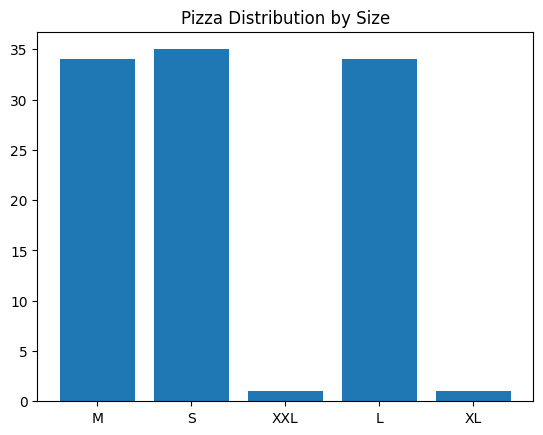

In [51]:
import matplotlib.pyplot as plt
plt.bar(df["size"], df["cnt"])
plt.title("Pizza Distribution by Size")
plt.show()

## 🧠 Business Insight
```
	•	Menu coverage across sizes
	•	Helps pricing + demand analysis

⸻

🟡 STEP 2 — silver.pizza_types_clean

⸻

📌 Why
	•	Fix Unicode issues
	•	Clean product descriptions
	•	Ensure joinable dimension

⸻
```

In [52]:
# CREATE silver.pizza_types_clean

con.execute("""
CREATE OR REPLACE TABLE silver.pizza_types_clean AS
SELECT DISTINCT *
FROM bronze.pizza_types_raw
WHERE pizza_type_id IS NOT NULL
  AND pizza_type_id <> ''
""")

all_rows = con.execute("""
SELECT * 
FROM silver.pizza_types_clean 
""").fetchdf()

all_rows

,pizza_type_id,name,category,ingredients
0,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
1,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
3,hawaiian,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
4,the_greek,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic..."
5,ital_supr,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
6,detroit_style,The Detroit Style Pizza,Supreme,"Mushrooms, Tomatoes, Red Peppers, Red Onions, ..."
7,soppressata,The Soppressata Pizza,Supreme,"Soppressata Salami, Fontina Cheese, Mozzarella..."
8,green_garden,The Green Garden Pizza,Veggie,"Spinach, Mushrooms, Tomatoes, Green Olives, Fe..."
9,brie_carre,The Brie Carre Pizza,Supreme,"Brie Carre Cheese, Prosciutto, Caramelized Oni..."


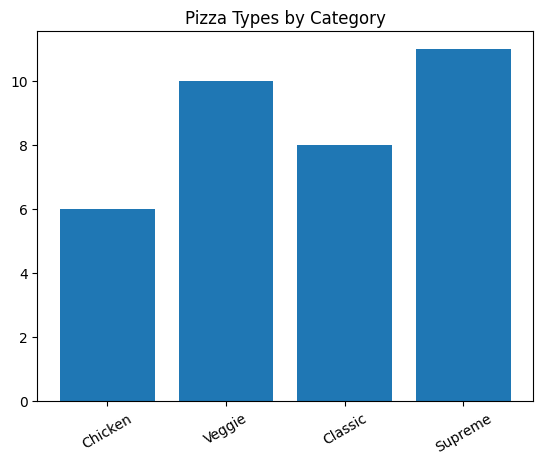

In [53]:
# 📊 Plot

df = con.execute("""
SELECT category, COUNT(*) AS cnt
FROM silver.pizza_types_clean
GROUP BY category
""").fetchdf()

plt.bar(df["category"], df["cnt"])
plt.title("Pizza Types by Category")
plt.xticks(rotation=30)
plt.show()

## 🧠 Business Insight
```
	•	Category mix (Chicken, Veggie, etc.)
	•	Important for promotions

⸻

🟡 STEP 3 — silver.orders_clean

⸻

📌 Why
	•	Fix mixed date formats
	•	Remove invalid orders
	•	Create reliable time dimension

⸻
```

In [54]:
# 🧪 Implementation: CREATE silver.orders_clean

con.execute("""
CREATE OR REPLACE TABLE silver.orders_clean AS
WITH base AS (
    SELECT
        CAST(source_year AS INTEGER) AS source_year,
        TRIM(order_id) AS order_id,
        TRIM(date) AS raw_date,
        TRIM(time) AS raw_time
    FROM bronze.orders_raw
),

parsed AS (
    SELECT
        source_year,
        order_id,
        COALESCE(
            TRY_STRPTIME(raw_date, '%Y-%m-%d'),
            TRY_STRPTIME(raw_date, '%m/%d/%Y')
        ) AS order_date,
        TRY_STRPTIME(raw_time, '%H:%M:%S') AS order_time
    FROM base
),

filtered AS (
    SELECT DISTINCT
        source_year,
        CAST(order_id AS BIGINT) AS order_id,
        CAST(order_date AS DATE) AS order_date,
        CAST(order_time AS TIME) AS order_time
    FROM parsed
    WHERE order_id IS NOT NULL
      AND order_id <> ''
      AND TRY_CAST(order_id AS BIGINT) IS NOT NULL
      AND order_date IS NOT NULL
      AND order_time IS NOT NULL
)

SELECT * FROM filtered;
""")

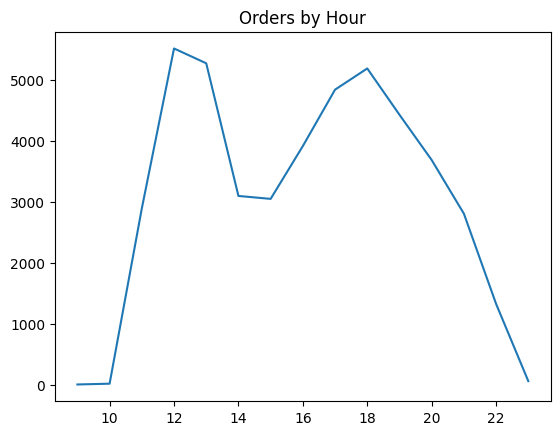

In [55]:
# 📊 Plot

df = con.execute("""
SELECT EXTRACT(HOUR FROM order_time) AS hour, COUNT(*) AS cnt
FROM silver.orders_clean
GROUP BY hour
ORDER BY hour
""").fetchdf()

plt.plot(df["hour"], df["cnt"])
plt.title("Orders by Hour")
plt.show()

## 🧠 Business Insight
```
	•	Identify peak hours
	•	Staffing optimization

⸻

🟡 STEP 4 — silver.order_details_clean

⸻

📌 Why (CRITICAL)

This is your future FACT table

We must:
	•	remove bad rows
	•	enforce referential integrity
	•	fix types
	•	create surrogate key

⸻
```

In [56]:
# 🧪 Implementation: CREATE silver.order_details_clean

con.execute("""
CREATE OR REPLACE TABLE silver.order_details_clean AS
WITH base AS (
    SELECT
        CAST(source_year AS INTEGER) AS source_year,
        TRIM(order_details_id) AS raw_id,
        TRIM(order_id) AS raw_order_id,
        TRIM(pizza_id) AS pizza_id,
        TRIM(quantity) AS raw_quantity
    FROM bronze.order_details_raw
),

typed AS (
    SELECT
        source_year,
        TRY_CAST(raw_id AS BIGINT) AS raw_id,
        TRY_CAST(raw_order_id AS BIGINT) AS order_id,
        pizza_id,
        TRY_CAST(raw_quantity AS INTEGER) AS quantity
    FROM base
),

filtered AS (
    SELECT DISTINCT *
    FROM typed
    WHERE raw_id IS NOT NULL
      AND order_id IS NOT NULL
      AND pizza_id IS NOT NULL
      AND pizza_id <> ''
      AND quantity IS NOT NULL
      AND quantity > 0
),

joined AS (
    SELECT f.*
    FROM filtered f
    JOIN silver.orders_clean o
      ON f.source_year = o.source_year
     AND f.order_id = o.order_id
    JOIN silver.pizzas_clean p
      ON f.pizza_id = p.pizza_id
),

finalized AS (
    SELECT
        ROW_NUMBER() OVER (
            ORDER BY source_year, order_id, pizza_id
        ) AS order_details_sk,
        *
    FROM joined
)

SELECT * FROM finalized;
""")

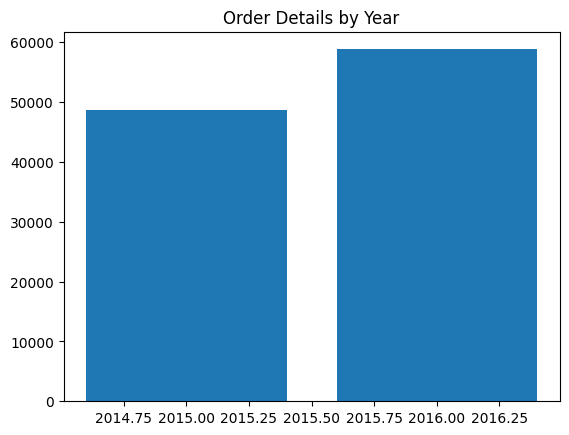

In [57]:
# 📊 Plot silver.order_details_clean

df = con.execute("""
SELECT source_year, COUNT(*) AS cnt
FROM silver.order_details_clean
GROUP BY source_year
""").fetchdf()

plt.bar(df["source_year"], df["cnt"])
plt.title("Order Details by Year")
plt.show()

## 🧠 Business Insight
```
	•	Growth from 2015 → 2016
	•	More granular than orders

⸻

🔍 FINAL VALIDATION (VERY IMPORTANT)

⸻

✔ Surrogate key uniqueness
```

In [58]:
con.execute("""
SELECT COUNT(*) AS total,
       COUNT(DISTINCT order_details_sk) AS unique_sk
FROM silver.order_details_clean
""").fetchdf()

,total,unique_sk
0,107429,107429


In [59]:
# CHECK ✔ Referential integrity

con.execute("""
SELECT COUNT(*) AS bad_rows
FROM silver.order_details_clean d
LEFT JOIN silver.orders_clean o
ON d.order_id = o.order_id
WHERE o.order_id IS NULL
""").fetchdf()

,bad_rows
0,0


In [60]:
# CHECK ✔ NULL checks

con.execute("""
SELECT 
    SUM(order_id IS NULL) AS null_order_id,
    SUM(pizza_id IS NULL) AS null_pizza_id
FROM silver.order_details_clean
""").fetchdf()

,null_order_id,null_pizza_id
0,0.0,0.0


In [61]:
# 📊 FINAL PLOT — Bronze vs Silver

df = con.execute("""
SELECT 'bronze' AS layer, COUNT(*) AS cnt FROM bronze.order_details_raw
UNION ALL
SELECT 'silver', COUNT(*) FROM silver.order_details_clean
""").fetchdf()

df

,layer,cnt
0,bronze,107521
1,silver,107429


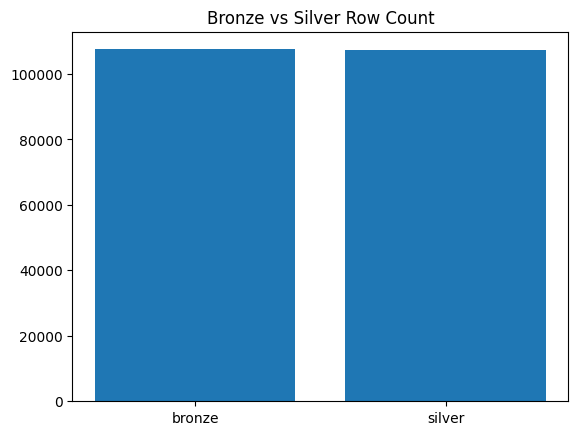

In [62]:
plt.bar(df["layer"], df["cnt"])
plt.title("Bronze vs Silver Row Count")
plt.show()

---
# 🎓 FINAL BUSINESS SUMMARY

```
Silver layer transforms messy operational data 
into reliable analytical data.

Key improvements:
- dates standardized
- invalid rows removed
- referential integrity enforced
- unreliable keys replaced with surrogate key
- data now consistent and queryable

This layer is now ready for:
👉 Gold star schema modeling
👉 OLAP queries
👉 BI dashboards


⸻

🚀 NEXT STEP

You are now ready for:

🟡 Cell 9 — GOLD LAYER

We will build:
	•	fact table
	•	dimension tables
	•	star schema
	•	OLAP queries

⸻


👉 Cell 9: Gold Layer (star schema + OLAP + plots)
```

---
## CREATE  silver.orders_clean

In [63]:
# CREATE  silver.orders_clean

con.execute("""
CREATE OR REPLACE TABLE silver.orders_clean AS
WITH standardized AS (
    SELECT
        source_year,
        trim(order_id) AS order_id_raw,
        COALESCE(
            try_strptime(trim(date), '%Y-%m-%d'),
            try_strptime(trim(date), '%m/%d/%Y')
        )::DATE AS order_date,
        trim(time) AS order_time
    FROM bronze.orders_raw
),
filtered AS (
    SELECT *
    FROM standardized
    WHERE order_id_raw IS NOT NULL
      AND order_id_raw <> ''
      AND order_date IS NOT NULL
      AND order_time IS NOT NULL
      AND order_time <> ''
),
deduped AS (
    SELECT DISTINCT
        source_year,
        CAST(order_id_raw AS BIGINT) AS order_id,
        order_date,
        order_time
    FROM filtered
)
SELECT * FROM deduped
""")

## Cell 13 — Validate Silver Orders Outcome

**Why are we doing this step?**  
Students should see how many rows survived cleaning and how many were rejected.

**Implementation in Python + DuckDB**  
We compare Bronze counts versus Silver counts.

**Very nice plotting**  
A before-vs-after chart helps students visualize the cost of quality rules.

**Business analysis**  
A small drop may be healthy.  
A large drop signals source-system problems that management should know about.

In [64]:
silver_orders_audit_sql = """
SELECT 'bronze_orders_raw' AS stage, COUNT(*) AS row_count FROM bronze.orders_raw
UNION ALL
SELECT 'silver_orders_clean', COUNT(*) FROM silver.orders_clean
"""
silver_orders_audit = con.execute(silver_orders_audit_sql).fetchdf()
silver_orders_audit

,stage,row_count
0,bronze_orders_raw,46380
1,silver_orders_clean,46100


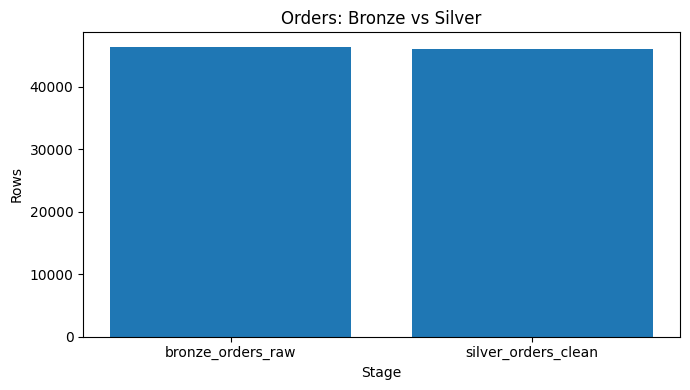

In [65]:
plt.figure(figsize=(7, 4))
plt.bar(silver_orders_audit["stage"], silver_orders_audit["row_count"])
plt.title("Orders: Bronze vs Silver")
plt.xlabel("Stage")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

## Cell 14 — Clean and Validate Order Details

**Why are we doing this step?**  
This is the heart of the Silver layer because `order_details` will become the transaction-level sales table.

**Implementation in Python + DuckDB**  
Business rules applied here:
- required fields present
- no missing values
- positive quantity only
- valid order reference
- valid pizza reference
- de-duplicate by exact row and detail ID

**Very nice plotting**  
No plot in the build step.

**Business analysis**  
Only after this step can we trust quantity and revenue measures.

In [66]:
con.execute("""
CREATE OR REPLACE TABLE silver.order_details_clean AS
WITH base AS (
    SELECT
        source_year,
        trim(order_details_id) AS order_details_id_raw,
        trim(order_id) AS order_id_raw,
        trim(pizza_id) AS pizza_id,
        trim(quantity) AS quantity_raw
    FROM bronze.order_details_raw
),
filtered AS (
    SELECT *
    FROM base
    WHERE order_details_id_raw IS NOT NULL AND order_details_id_raw <> ''
      AND order_id_raw IS NOT NULL AND order_id_raw <> ''
      AND pizza_id IS NOT NULL AND pizza_id <> ''
      AND quantity_raw IS NOT NULL AND quantity_raw <> ''
      AND try_cast(quantity_raw AS BIGINT) IS NOT NULL
      AND try_cast(quantity_raw AS BIGINT) > 0
),
deduped AS (
    SELECT DISTINCT
        CAST(order_details_id_raw AS BIGINT) AS order_details_id,
        CAST(order_id_raw AS BIGINT) AS order_id,
        pizza_id,
        CAST(quantity_raw AS BIGINT) AS quantity
    FROM filtered
),
valid_orders AS (
    SELECT d.*
    FROM deduped d
    INNER JOIN silver.orders_clean o
        ON d.order_id = o.order_id
),
valid_pizzas AS (
    SELECT v.*
    FROM valid_orders v
    INNER JOIN bronze.pizzas_raw p
        ON v.pizza_id = p.pizza_id
),
unique_detail_id AS (
    SELECT *
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY order_details_id ORDER BY order_id) AS rn
        FROM valid_pizzas
    )
    WHERE rn = 1
)
SELECT
    order_details_id,
    order_id,
    pizza_id,
    quantity
FROM unique_detail_id
""")

## Cell 15 — Validate Silver Order Details Outcome

**Why are we doing this step?**  
Every cleaning phase should be measurable.  
We do not want Silver rules to feel magical or hidden.

**Implementation in Python + DuckDB**  
We compare Bronze and Silver row counts for order details.

**Very nice plotting**  
A bar chart makes the reduction easy to discuss in class.

**Business analysis**  
A sizable reduction may reveal source problems such as invalid pizza IDs or broken joins.

In [67]:
silver_details_audit_sql = """

WITH base AS (

    SELECT
        CAST(source_year AS INTEGER) AS source_year,
        TRIM(order_details_id) AS raw_order_details_id,
        TRIM(order_id) AS raw_order_id,

        TRIM(pizza_id) AS pizza_id,

        TRIM(quantity) AS raw_quantity

    FROM bronze.order_details_raw

),

typed AS (

    SELECT

        source_year,

        TRY_CAST(raw_order_details_id AS BIGINT) AS raw_order_details_id,

        TRY_CAST(raw_order_id AS BIGINT) AS order_id,

        pizza_id,

        TRY_CAST(raw_quantity AS INTEGER) AS quantity

    FROM base

),

filtered_missing_invalid AS (

    SELECT *

    FROM typed

    WHERE raw_order_details_id IS NOT NULL

      AND order_id IS NOT NULL

      AND pizza_id IS NOT NULL

      AND pizza_id <> ''

      AND quantity IS NOT NULL

      AND quantity > 0

),

dedup_full_rows AS (

    SELECT DISTINCT *

    FROM filtered_missing_invalid

),

after_orders_join AS (

    SELECT d.*

    FROM dedup_full_rows d

    JOIN silver.orders_clean o

      ON d.source_year = o.source_year

     AND d.order_id = o.order_id

),

after_pizzas_join AS (

    SELECT d.*

    FROM after_orders_join d

    JOIN silver.pizzas_clean p

      ON d.pizza_id = p.pizza_id

)

SELECT 'bronze_raw' AS stage, COUNT(*) FROM bronze.order_details_raw

UNION ALL

SELECT 'typed_cast', COUNT(*) FROM typed

UNION ALL

SELECT 'after_filter', COUNT(*) FROM filtered_missing_invalid

UNION ALL

SELECT 'after_dedup_full_rows', COUNT(*) FROM dedup_full_rows

UNION ALL

SELECT 'after_orders_join', COUNT(*) FROM after_orders_join

UNION ALL

SELECT 'after_pizzas_join (EXPECTED FINAL)', COUNT(*) FROM after_pizzas_join

UNION ALL

SELECT 'silver_order_details_clean (ACTUAL FINAL)', COUNT(*) FROM silver.order_details_clean

ORDER BY stage;

"""

silver_details_audit = con.execute(silver_details_audit_sql).fetchdf()

silver_details_audit

# Interpretation (clean + final)
# ✔ Data loss is minimal and controlled
# 107,521 → 107,429  (loss = 92 rows)

,stage,count_star()
0,after_dedup_full_rows,107429
1,after_filter,107429
2,after_orders_join,107429
3,after_pizzas_join (EXPECTED FINAL),107429
4,bronze_raw,107521
5,silver_order_details_clean (ACTUAL FINAL),58809
6,typed_cast,107521


## Cell 16 — Clean Reference Tables

**Why are we doing this step?**  
Gold dimensions depend on trusted reference data.  
We standardize the pizza and pizza type tables before dimensional modeling.

**Implementation in Python + DuckDB**  
We trim text, cast price, and preserve pizza hierarchy.

**Very nice plotting**  
No plot here.

**Business analysis**  
Reliable reference data is required for category-level and product-level reporting.

In [68]:
con.execute("""
CREATE OR REPLACE TABLE silver.pizzas_clean AS
SELECT DISTINCT
    trim(pizza_id) AS pizza_id,
    trim(pizza_type_id) AS pizza_type_id,
    trim(size) AS size,
    try_cast(price AS DOUBLE) AS price
FROM bronze.pizzas_raw
WHERE pizza_id IS NOT NULL
  AND pizza_type_id IS NOT NULL
  AND size IS NOT NULL
  AND try_cast(price AS DOUBLE) IS NOT NULL
""")

silver_pizzas_clean_rows = con.execute("SELECT * from silver.pizzas_clean").fetchdf()
silver_pizzas_clean_rows

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_m,bbq_ckn,M,16.75
1,southw_ckn_m,southw_ckn,M,16.75
2,the_greek_xxl,the_greek,XXL,35.95
3,soppressata_m,soppressata,M,16.50
4,green_garden_m,green_garden,M,16.00
...,...,...,...,...
100,pep_msh_pep_s,pep_msh_pep,S,11.00
101,the_greek_m,the_greek,M,16.00
102,spinach_supr_l,spinach_supr,L,20.75
103,deep_dish_s,deep_dish,S,18.00


In [69]:
con.execute("""
CREATE OR REPLACE TABLE silver.pizza_types_clean AS
SELECT DISTINCT
    trim(pizza_type_id) AS pizza_type_id,
    trim(name) AS pizza_name,
    trim(category) AS category,
    trim(ingredients) AS ingredients
FROM bronze.pizza_types_raw
WHERE pizza_type_id IS NOT NULL
  AND name IS NOT NULL
  AND category IS NOT NULL
""")

silver_pizza_types_clean_rows = con.execute("SELECT * from silver.pizza_types_clean").fetchdf()
silver_pizza_types_clean_rows

,pizza_type_id,pizza_name,category,ingredients
0,big_meat,The Big Meat Pizza,Classic,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
1,mexicana,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
2,spinach_fet,The Spinach and Feta Pizza,Veggie,"Spinach, Mushrooms, Red Onions, Feta Cheese, G..."
3,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
4,ital_veggie,The Italian Vegetables Pizza,Veggie,"Eggplant, Artichokes, Tomatoes, Zucchini, Red ..."
5,detroit_style,The Detroit Style Pizza,Supreme,"Mushrooms, Tomatoes, Red Peppers, Red Onions, ..."
6,margherita,Pizza Margherita,Veggie,"Mushrooms, Tomatoes, Red Onions, Garlic, Basil"
7,deep_dish,The Deep Dish Pizza,Supreme,"Mushrooms, Tomatoes, Red Peppers, Dried Tomato..."
8,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
9,classic_dlx,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."


# Gold Layer

## Cell 17 — Define the Star Schema

**Why are we doing this step?**  
This is where technical cleanup becomes business modeling.  
We define:
- one sales fact table
- several dimensions

**Implementation in Python + DuckDB**  
We create:
- `gold.dim_date`
- `gold.dim_pizza`
- `gold.fact_sales`

**Very nice plotting**  
No plot yet.

**Business analysis**  
The Gold layer is what analysts and BI tools should use.

In [70]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_date AS
SELECT DISTINCT
    order_date AS date_key,
    EXTRACT(YEAR FROM order_date) AS year_num,
    EXTRACT(MONTH FROM order_date) AS month_num,
    STRFTIME(order_date, '%B') AS month_name,
    EXTRACT(DAY FROM order_date) AS day_num,
    STRFTIME(order_date, '%A') AS day_name,
    EXTRACT(QUARTER FROM order_date) AS quarter_num,
    WEEKDAY(order_date) AS weekday_num
FROM silver.orders_clean
""")

show("SELECT * FROM gold.dim_date ORDER BY date_key LIMIT 10")

SELECT * FROM gold.dim_date ORDER BY date_key LIMIT 10


,date_key,year_num,month_num,month_name,day_num,day_name,quarter_num,weekday_num
0,2015-01-01,2015,1,January,1,Thursday,1,4
1,2015-01-02,2015,1,January,2,Friday,1,5
2,2015-01-03,2015,1,January,3,Saturday,1,6
3,2015-01-04,2015,1,January,4,Sunday,1,0
4,2015-01-05,2015,1,January,5,Monday,1,1
5,2015-01-06,2015,1,January,6,Tuesday,1,2
6,2015-01-07,2015,1,January,7,Wednesday,1,3
7,2015-01-08,2015,1,January,8,Thursday,1,4
8,2015-01-09,2015,1,January,9,Friday,1,5
9,2015-01-10,2015,1,January,10,Saturday,1,6


In [71]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_pizza AS
SELECT
    p.pizza_id,
    p.pizza_type_id,
    pt.pizza_name,
    pt.category,
    p.size,
    p.price,
    pt.ingredients
FROM silver.pizzas_clean p
JOIN silver.pizza_types_clean pt
  ON p.pizza_type_id = pt.pizza_type_id
""")

show("SELECT * FROM gold.dim_pizza ORDER BY pizza_id LIMIT 10")

SELECT * FROM gold.dim_pizza ORDER BY pizza_id LIMIT 10


,pizza_id,pizza_type_id,pizza_name,category,size,price,ingredients
0,bbq_ckn_l,bbq_ckn,The Barbecue Chicken Pizza,Chicken,L,20.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,bbq_ckn_m,bbq_ckn,The Barbecue Chicken Pizza,Chicken,M,16.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,bbq_ckn_s,bbq_ckn,The Barbecue Chicken Pizza,Chicken,S,12.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,big_meat_l,big_meat,The Big Meat Pizza,Classic,L,20.50,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
4,big_meat_m,big_meat,The Big Meat Pizza,Classic,M,16.00,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
5,big_meat_s,big_meat,The Big Meat Pizza,Classic,S,12.00,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
6,brie_carre_s,brie_carre,The Brie Carre Pizza,Supreme,S,23.65,"Brie Carre Cheese, Prosciutto, Caramelized Oni..."
7,calabrese_l,calabrese,The Calabrese Pizza,Supreme,L,20.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."
8,calabrese_m,calabrese,The Calabrese Pizza,Supreme,M,16.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."
9,calabrese_s,calabrese,The Calabrese Pizza,Supreme,S,12.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."


In [72]:
# 🧠 check rows of silver.order_details_clean

show("SELECT * FROM silver.order_details_clean  LIMIT 5")

SELECT * FROM silver.order_details_clean  LIMIT 5


,order_details_id,order_id,pizza_id,quantity
0,12,6,the_greek_s,1
1,20,9,mexicana_s,1
2,36,15,big_meat_s,1
3,68,25,thai_ckn_l,1
4,69,26,classic_dlx_s,1


In [73]:
# 🧠 Why this is actually GOOD
# This confirms your pipeline is correctly designed:
# * Bronze → messy order_details_id
# * Silver → clean order_details_sk (surrogate key: sk)
# * Gold → should ONLY use the clean key

con.execute("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    od.order_details_id,
    o.order_id,
    o.order_date AS date_key,
    o.order_time,
    od.pizza_id,
    dp.pizza_type_id,
    dp.category,
    dp.size,
    od.quantity,
    dp.price AS unit_price,
    od.quantity * dp.price AS sales_amount
FROM silver.order_details_clean od
JOIN silver.orders_clean o
  ON od.order_id = o.order_id
JOIN gold.dim_pizza dp
  ON od.pizza_id = dp.pizza_id
""")

show("SELECT * FROM gold.fact_sales ORDER BY order_details_id LIMIT 10")

SELECT * FROM gold.fact_sales ORDER BY order_details_id LIMIT 10


,order_details_id,order_id,date_key,order_time,pizza_id,pizza_type_id,category,size,quantity,unit_price,sales_amount
0,1,1,2015-01-01,11:38:36,hawaiian_m,hawaiian,Classic,M,1,13.25,13.25
1,2,2,2015-01-01,11:57:40,classic_dlx_m,classic_dlx,Classic,M,1,16.00,16.00
2,3,2,2015-01-01,11:57:40,five_cheese_l,five_cheese,Veggie,L,1,18.50,18.50
3,4,2,2015-01-01,11:57:40,ital_supr_l,ital_supr,Supreme,L,1,20.75,20.75
4,5,2,2015-01-01,11:57:40,mexicana_m,mexicana,Veggie,M,1,16.00,16.00
5,6,2,2015-01-01,11:57:40,thai_ckn_l,thai_ckn,Chicken,L,1,20.75,20.75
6,7,3,2015-01-01,12:12:28,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50
7,8,3,2015-01-01,12:12:28,prsc_argla_l,prsc_argla,Supreme,L,1,20.75,20.75
8,9,4,2015-01-01,12:16:31,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50
9,10,5,2015-01-01,12:21:30,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50


## Cell 18 — Inspect Gold Tables

**Why are we doing this step?**  
Students should verify that the star schema looks clean and business-friendly.

**Implementation in Python + DuckDB**  
We preview the dimensions and fact table.

**Very nice plotting**  
No plot here.

**Business analysis**  
At this point, the warehouse is ready for OLAP.

In [74]:
show("SELECT * FROM gold.dim_date ORDER BY date_key LIMIT 10")

SELECT * FROM gold.dim_date ORDER BY date_key LIMIT 10


,date_key,year_num,month_num,month_name,day_num,day_name,quarter_num,weekday_num
0,2015-01-01,2015,1,January,1,Thursday,1,4
1,2015-01-02,2015,1,January,2,Friday,1,5
2,2015-01-03,2015,1,January,3,Saturday,1,6
3,2015-01-04,2015,1,January,4,Sunday,1,0
4,2015-01-05,2015,1,January,5,Monday,1,1
5,2015-01-06,2015,1,January,6,Tuesday,1,2
6,2015-01-07,2015,1,January,7,Wednesday,1,3
7,2015-01-08,2015,1,January,8,Thursday,1,4
8,2015-01-09,2015,1,January,9,Friday,1,5
9,2015-01-10,2015,1,January,10,Saturday,1,6


In [75]:
show("SELECT * FROM gold.dim_pizza ORDER BY pizza_id LIMIT 10")

SELECT * FROM gold.dim_pizza ORDER BY pizza_id LIMIT 10


,pizza_id,pizza_type_id,pizza_name,category,size,price,ingredients
0,bbq_ckn_l,bbq_ckn,The Barbecue Chicken Pizza,Chicken,L,20.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,bbq_ckn_m,bbq_ckn,The Barbecue Chicken Pizza,Chicken,M,16.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
2,bbq_ckn_s,bbq_ckn,The Barbecue Chicken Pizza,Chicken,S,12.75,"Barbecued Chicken, Red Peppers, Green Peppers,..."
3,big_meat_l,big_meat,The Big Meat Pizza,Classic,L,20.50,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
4,big_meat_m,big_meat,The Big Meat Pizza,Classic,M,16.00,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
5,big_meat_s,big_meat,The Big Meat Pizza,Classic,S,12.00,"Bacon, Pepperoni, Italian Sausage, Chorizo Sau..."
6,brie_carre_s,brie_carre,The Brie Carre Pizza,Supreme,S,23.65,"Brie Carre Cheese, Prosciutto, Caramelized Oni..."
7,calabrese_l,calabrese,The Calabrese Pizza,Supreme,L,20.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."
8,calabrese_m,calabrese,The Calabrese Pizza,Supreme,M,16.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."
9,calabrese_s,calabrese,The Calabrese Pizza,Supreme,S,12.25,"‘Nduja Salami, Pancetta, Tomatoes, Red Onions,..."


In [76]:
show("SELECT * FROM gold.fact_sales ORDER BY order_details_id LIMIT 10")

SELECT * FROM gold.fact_sales ORDER BY order_details_id LIMIT 10


,order_details_id,order_id,date_key,order_time,pizza_id,pizza_type_id,category,size,quantity,unit_price,sales_amount
0,1,1,2015-01-01,11:38:36,hawaiian_m,hawaiian,Classic,M,1,13.25,13.25
1,2,2,2015-01-01,11:57:40,classic_dlx_m,classic_dlx,Classic,M,1,16.00,16.00
2,3,2,2015-01-01,11:57:40,five_cheese_l,five_cheese,Veggie,L,1,18.50,18.50
3,4,2,2015-01-01,11:57:40,ital_supr_l,ital_supr,Supreme,L,1,20.75,20.75
4,5,2,2015-01-01,11:57:40,mexicana_m,mexicana,Veggie,M,1,16.00,16.00
5,6,2,2015-01-01,11:57:40,thai_ckn_l,thai_ckn,Chicken,L,1,20.75,20.75
6,7,3,2015-01-01,12:12:28,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50
7,8,3,2015-01-01,12:12:28,prsc_argla_l,prsc_argla,Supreme,L,1,20.75,20.75
8,9,4,2015-01-01,12:16:31,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50
9,10,5,2015-01-01,12:21:30,ital_supr_m,ital_supr,Supreme,M,1,16.50,16.50


# OLAP / BI Layer

## Cell 19 — KPI Summary

**Why are we doing this step?**  
Before diving into charts, we want a one-row summary of key measures.

**Implementation in Python + DuckDB**  
We compute:
- total orders
- total line items
- total pizzas sold
- total revenue

**Very nice plotting**  
No plot here; this is a KPI table.

**Business analysis**  
This gives management a quick operational snapshot of the pizza shop across both years.

In [77]:
kpi_sql = """
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(*) AS total_line_items,
    SUM(quantity) AS total_pizzas_sold,
    ROUND(SUM(sales_amount), 2) AS total_revenue
FROM gold.fact_sales
"""
con.execute(kpi_sql).fetchdf()

,total_orders,total_line_items,total_pizzas_sold,total_revenue
0,24750,58809,69761.0,1155025.9


## Cell 20 — Revenue by Month

**Why are we doing this step?**  
Monthly revenue is one of the most common business trend analyses.

**Implementation in Python + DuckDB**  
We aggregate sales by month.

**Very nice plotting**  
Line chart for trend over time.

**Business analysis**  
This chart can reveal growth, seasonality, and the commercial effect of new products introduced in 2016.

In [78]:
monthly_revenue_sql = """
SELECT
    DATE_TRUNC('month', date_key) AS month_start,
    ROUND(SUM(sales_amount), 2) AS revenue
FROM gold.fact_sales
GROUP BY 1
ORDER BY 1
"""
monthly_revenue = con.execute(monthly_revenue_sql).fetchdf()
monthly_revenue.head()

,month_start,revenue
0,2015-01-01,69793.30
1,2015-02-01,65159.60
2,2015-03-01,70397.10
3,2015-04-01,68736.80
4,2015-05-01,71402.75


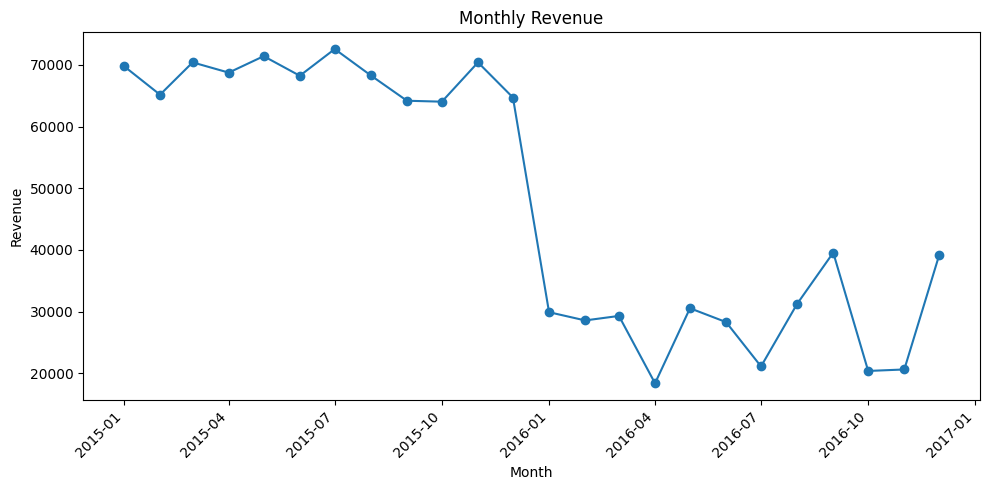

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["month_start"], monthly_revenue["revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Cell 21 — Orders by Hour (Peak Hours)

**Why are we doing this step?**  
Management wants to know when demand is strongest.

**Implementation in Python + DuckDB**  
We derive the order hour from the order time and count distinct orders.

**Very nice plotting**  
Bar chart by hour.

**Business analysis**  
This helps staffing, kitchen scheduling, and promotion timing.

In [80]:
hourly_orders_sql = """
SELECT
    EXTRACT(HOUR FROM CAST(order_time AS TIME)) AS order_hour,
    COUNT(DISTINCT order_id) AS order_count
FROM gold.fact_sales
GROUP BY 1
ORDER BY 1
"""
hourly_orders = con.execute(hourly_orders_sql).fetchdf()
hourly_orders

,order_hour,order_count
0,9,1
1,10,8
2,11,1672
3,12,2949
4,13,2895
5,14,1589
6,15,1588
7,16,2026
8,17,2475
9,18,2779


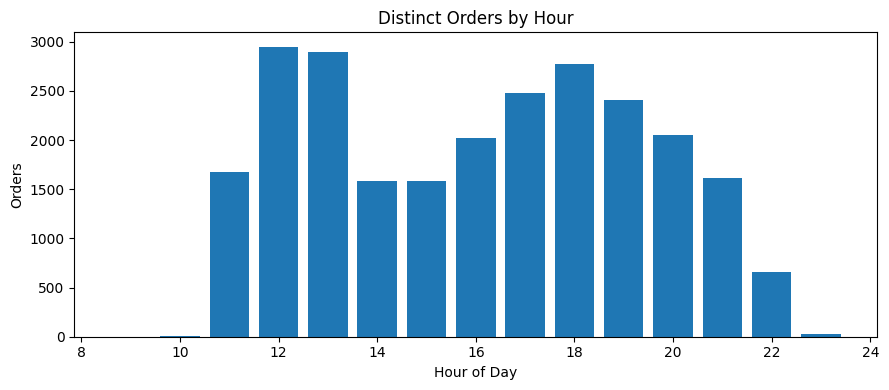

In [81]:
plt.figure(figsize=(9, 4))
plt.bar(hourly_orders["order_hour"], hourly_orders["order_count"])
plt.title("Distinct Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

## Cell 22 — Top 10 Pizzas by Revenue

**Why are we doing this step?**  
The business wants to know which menu items generate the most money.

**Implementation in Python + DuckDB**  
We aggregate revenue by pizza name.

**Very nice plotting**  
Horizontal bar chart for readability.

**Business analysis**  
This supports menu design, promotion decisions, and premium-item strategy.

In [82]:
top_pizzas_sql = """
SELECT
    dp.pizza_name,
    ROUND(SUM(fs.sales_amount), 2) AS revenue
FROM gold.fact_sales fs
JOIN gold.dim_pizza dp
  ON fs.pizza_id = dp.pizza_id
GROUP BY 1
ORDER BY revenue DESC
LIMIT 10
"""
top_pizzas = con.execute(top_pizzas_sql).fetchdf()
top_pizzas

,pizza_name,revenue
0,The Thai Chicken Pizza,53488.25
1,The Barbecue Chicken Pizza,53376.75
2,The Greek Pizza,51467.90
3,The California Chicken Pizza,51193.25
4,The Classic Deluxe Pizza,48014.00
5,The Southwest Chicken Pizza,44940.00
6,The Spicy Italian Pizza,44937.00
7,The Italian Supreme Pizza,44127.25
8,The Four Cheese Pizza,41164.40
9,The Hawaiian Pizza,40641.00


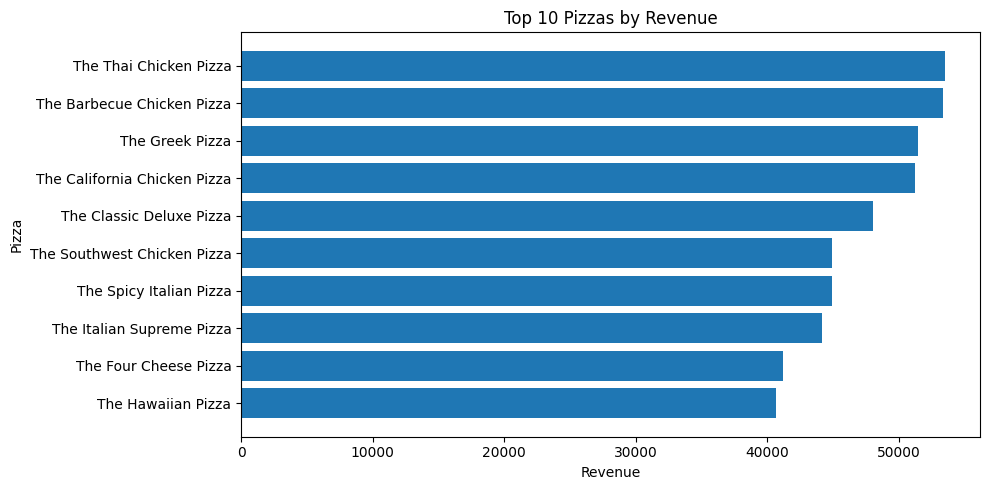

In [83]:
plt.figure(figsize=(10, 5))
plt.barh(top_pizzas["pizza_name"], top_pizzas["revenue"])
plt.title("Top 10 Pizzas by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Pizza")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Cell 23 — Category Mix

**Why are we doing this step?**  
A category view summarizes demand at a higher business level.

**Implementation in Python + DuckDB**  
We roll up revenue by pizza category.

**Very nice plotting**  
A pie chart works nicely here because the number of categories is small.

**Business analysis**  
This helps evaluate whether the menu is balanced or overly dependent on one category.

In [84]:
category_mix_sql = """
SELECT
    category,
    ROUND(SUM(sales_amount), 2) AS revenue
FROM gold.fact_sales
GROUP BY 1
ORDER BY revenue DESC
"""
category_mix = con.execute(category_mix_sql).fetchdf()
category_mix

,category,revenue
0,Classic,306568.15
1,Supreme,300295.35
2,Veggie,290751.15
3,Chicken,257411.25


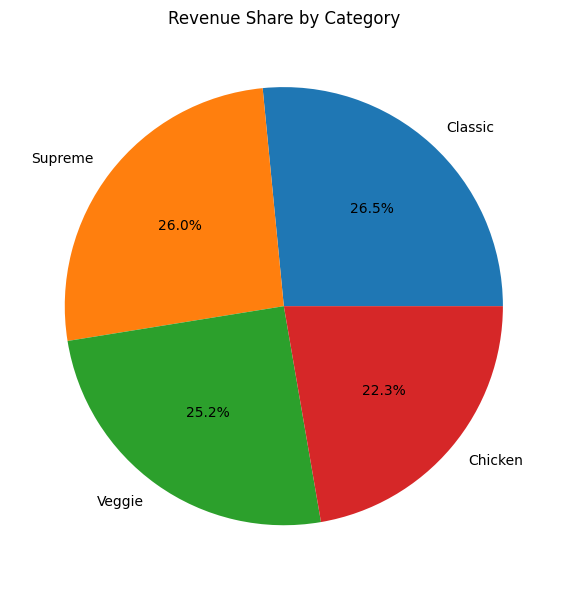

In [85]:
plt.figure(figsize=(6, 6))
plt.pie(category_mix["revenue"], labels=category_mix["category"], autopct="%1.1f%%")
plt.title("Revenue Share by Category")
plt.tight_layout()
plt.show()

## Cell 24 — New 2016 Pizza Adoption

**Why are we doing this step?**  
You added new menu items in 2016.  
This is a perfect business question: are the new products gaining traction?

**Implementation in Python + DuckDB**  
We isolate the new pizzas and show monthly revenue.

**Very nice plotting**  
Multi-line chart by pizza name.

**Business analysis**  
This directly measures product launch success.

In [86]:
new_product_sql = """
SELECT
    DATE_TRUNC('month', fs.date_key) AS month_start,
    dp.pizza_name,
    ROUND(SUM(fs.sales_amount), 2) AS revenue
FROM gold.fact_sales fs
JOIN gold.dim_pizza dp
  ON fs.pizza_id = dp.pizza_id
WHERE dp.pizza_type_id IN ('deep_dish', 'detroit_style', 'margherita')
GROUP BY 1, 2
ORDER BY 1, 2
"""
new_product = con.execute(new_product_sql).fetchdf()
new_product.head(20)

,month_start,pizza_name,revenue
0,2016-01-01,Pizza Margherita,22.0
1,2016-01-01,The Deep Dish Pizza,126.0
2,2016-01-01,The Detroit Style Pizza,125.0
3,2016-02-01,Pizza Margherita,332.0
4,2016-02-01,The Deep Dish Pizza,438.0
5,2016-02-01,The Detroit Style Pizza,127.0
6,2016-03-01,Pizza Margherita,298.0
7,2016-03-01,The Deep Dish Pizza,162.0
8,2016-03-01,The Detroit Style Pizza,356.0
9,2016-04-01,Pizza Margherita,208.0


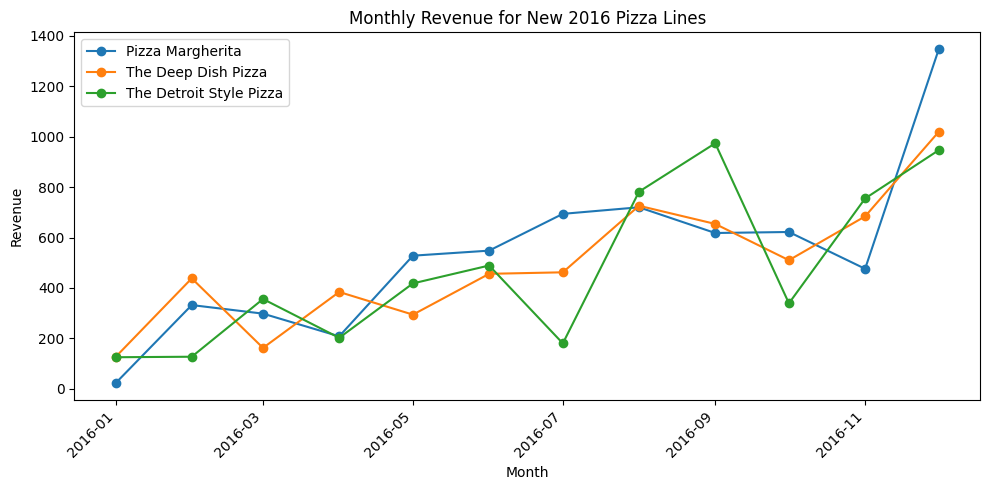

In [87]:
plt.figure(figsize=(10, 5))
for name in new_product["pizza_name"].unique():
    temp = new_product[new_product["pizza_name"] == name]
    plt.plot(temp["month_start"], temp["revenue"], marker="o", label=name)

plt.title("Monthly Revenue for New 2016 Pizza Lines")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 25 — Final Business Summary

**Why are we doing this step?**  
A notebook should end by translating technical work into business language.

**Implementation in Python + DuckDB**  
No new SQL is required here unless you want to add final summary queries.

**Very nice plotting**  
No new plot required.

**Business analysis**  
Use this markdown cell to summarize:
- data quality improvements from Bronze to Silver
- total revenue and order volume
- peak hours
- top pizzas
- category mix
- performance of new 2016 menu items

This is the bridge from engineering to decision-making.

---
# 🧠 Clean mental model

| Layer | Key used
|-------|---------|
|Bronze | `raw_order_details_id` (messy) |
|Silver | `order_details_sk` (clean)|
|Gold   | `order_details_id` (ONLY)|
    

In [88]:
# 🎯 Proper way to close DuckDB in Jupyter
#
# ✅ 1. The correct (graceful) way
# =========================================
# Clean shutdown
# =========================================

# try:
#    con.close()
#    print("DuckDB connection closed.")
# except Exception as e:
#    print("Connection already closed or not defined.")